📂 Loading Peak-Centered data...
✅ Loaded 9493 training samples.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)                 │ (None, 32)                  │           3,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting Final Training...
Epoch 1/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9491 - loss: 0.2895 - val_accuracy: 0.9796 - val_loss: 0.1056
Epoch 2/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9804 - loss: 0.0791 - val_accuracy: 0.9810 - val_loss: 0.0693
Epoch 3/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9831 - loss: 0.0575 - val_accuracy: 0.9824 - val_loss: 0.0602
Epoch 4/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9845 - loss: 0.0494 - val_accuracy: 0.9831 - val_loss: 0.0558
Epoch 5/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9854 - loss: 0.0448 - val_accuracy: 0.9838 - val_loss: 0.0539
Epoch 6/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9860 - loss: 0.0415 - val_accuracy: 0.9846 - val_loss: 0.0528
Epoch 7/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9862 - loss: 0.0390 - val_accuracy: 0.9846 - val_loss: 0.0509
Epoch 8/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9869 - l


✅ SUCCESS: Phase 2 Complete.
Weights saved to ./model_outputs. Ready for Phase 3 (Quantization).


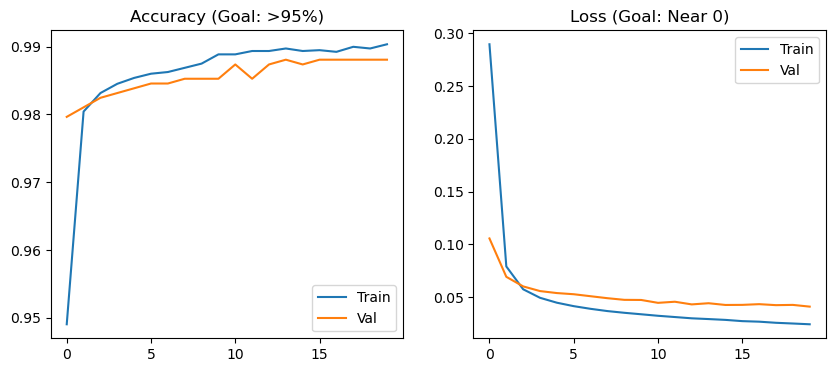

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURATION (Hardware Optimized) ---
INPUT_SIZE = 100    # 100-point ECG window
HIDDEN_NEURONS = 32 # Balanced for FPGA resource constraints
EPOCHS = 20         # With centered data, it will learn very fast
BATCH_SIZE = 32

# --- 2. LOAD CENTERED DATA ---
data_dir = './processed_data'

print("📂 Loading Peak-Centered data...")
try:
    X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
    y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
    X_test = np.load(os.path.join(data_dir, 'X_test.npy'))
    y_test = np.load(os.path.join(data_dir, 'y_test.npy'))
    print(f"✅ Loaded {len(X_train)} training samples.")
except FileNotFoundError:
    print("❌ ERROR: Could not find processed_data. Ensure the Recovery Script ran successfully.")
    exit()

# --- 3. BUILD MLP ARCHITECTURE ---
# Design: Input (100) -> Dense (32, ReLU) -> Dense (1, Sigmoid)
model = Sequential([
    Input(shape=(INPUT_SIZE,)),
    # ReLU: Simple hardware implementation (max(0, x))
    Dense(HIDDEN_NEURONS, activation='relu', name='hidden_layer'),
    # Sigmoid: Maps output to 0.0 - 1.0 probability
    Dense(1, activation='sigmoid', name='output_layer')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- 4. TRAINING ---
print("\n🚀 Starting Final Training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.15, # Use 15% of training for internal validation
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# --- 5. EVALUATION ---
print("\n📊 Final Performance on Test Set:")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# --- 6. WEIGHT EXTRACTION (BRIDGE TO VERILOG) ---
# We extract the math so we can hard-code it into the FPGA
output_dir = './model_outputs'
os.makedirs(output_dir, exist_ok=True)

# Extract Hidden Layer Weights (100 inputs x 32 neurons) and Biases (32)
w_hidden, b_hidden = model.get_layer('hidden_layer').get_weights()

# Extract Output Layer Weights (32 inputs x 1 neuron) and Bias (1)
w_output, b_output = model.get_layer('output_layer').get_weights()

# Save as .npy for Phase 3 (Quantization)
np.save(os.path.join(output_dir, 'w_hidden.npy'), w_hidden)
np.save(os.path.join(output_dir, 'b_hidden.npy'), b_hidden)
np.save(os.path.join(output_dir, 'w_output.npy'), w_output)
np.save(os.path.join(output_dir, 'b_output.npy'), b_output)

# Save the full model for reference
model.save(os.path.join(output_dir, 'heartbeat_model_final.h5'))

print(f"\n✅ SUCCESS: Phase 2 Complete.")
print(f"Weights saved to {output_dir}. Ready for Phase 3 (Quantization).")

# --- 7. VISUALIZE LEARNING ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy (Goal: >95%)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss (Goal: Near 0)')
plt.legend()
plt.show()